In [ ]:
import os
import sys
current_dir = os.path.abspath('.')

if os.path.basename(current_dir) == 'results':
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import *
from src.data import get_m4_data
from src.eda import TimeSeriesEDA
from src.clustering import TimeSeriesClustering

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

## 1. EDA
The experiment uses a sample from the M4 (Daily) dataset.
The goal of EDA is to evaluate time series parameters (stationarity, trend strength, and seasonality) to justify the need for transformations and the experimental parameters.

In [5]:
file_path = os.path.join(DATA_DIR, 'm4_daily_dataset.tsf')
series_dict = get_m4_data(filepath=file_path, n_samples=200)

Загрузка и фильтрация данных (Старт: 2010-01-01, Мин. длина: 150)

Отчет по предобработке датасета (отсечение до 2010-01-01):
Всего рядов собрано: 200
Рядов с пропусками внутри: 0
Рядов со сдвигом отрицательных/нулевых значений: 0
Мин. длина ряда: 150 дней


Translation:

Loading and filtering data (Start: 2010-01-01, Min. length: 150)

Dataset preprocessing report (cutoff to 2010-01-01):        
Total series collected: 200     
Series with gaps within: 0      
Series with shifted negative/zero values: 0     
Min. series length: 150 days

In [ ]:
target_year = 2012

def filter_series_by_year(series_dict, target_year=target_year, limit=50):
    filtered_ids = []
    for ts_id, series in series_dict.items():
        if any(series.index.year == target_year):
            filtered_ids.append(ts_id)
            
    print(f"Найдено рядов с {target_year} годом: {len(filtered_ids)}")
    return filtered_ids[:limit]

ts_options = filter_series_by_year(series_dict, target_year=target_year, limit=50)

Найдено рядов с 2012 годом: 265


Translation:

Number of rows found since 2012: 265

In [4]:
target_ids = ts_options[:5]

print(f"Анализируем 5 рядов: {target_ids}")

fig_stl = TimeSeriesEDA.plot_stl_multi(target_ids, series_dict, period=SEASONALITY)
fig_stl.show()

fig_corr = TimeSeriesEDA.plot_corr_multi(target_ids, series_dict, 50)
fig_corr.show()

Анализируем 5 рядов: ['T2246', 'T909', 'T1345', 'T464', 'T1310']


Translation:

We analyze 5 rows: ['T2246', 'T909', 'T1345', 'T464', 'T1310'].

**Conclusions from visual analysis:**

* Most series show a clear nonlinear trend, which overshadows the influence of seasonality. However, if we zoom out to the break of a year, rather than several years, we see a wave-like seasonality in the original and STL plots for the weekly period, although the decreasing ACF does not confirm this.
* Heteroscedasticity: the residual plots show noticeable spikes in variance, indicating instability of variance over time.
* Random walk: the ACF decreases very slowly (almost linearly), which is a marker of nonstationarity. The PACF peaks at the first lag, after which it drops sharply to zero.

Доля нестационарных рядов по ADF: 95.67%
Доля нестационарных рядов по KPSS: 96.33%


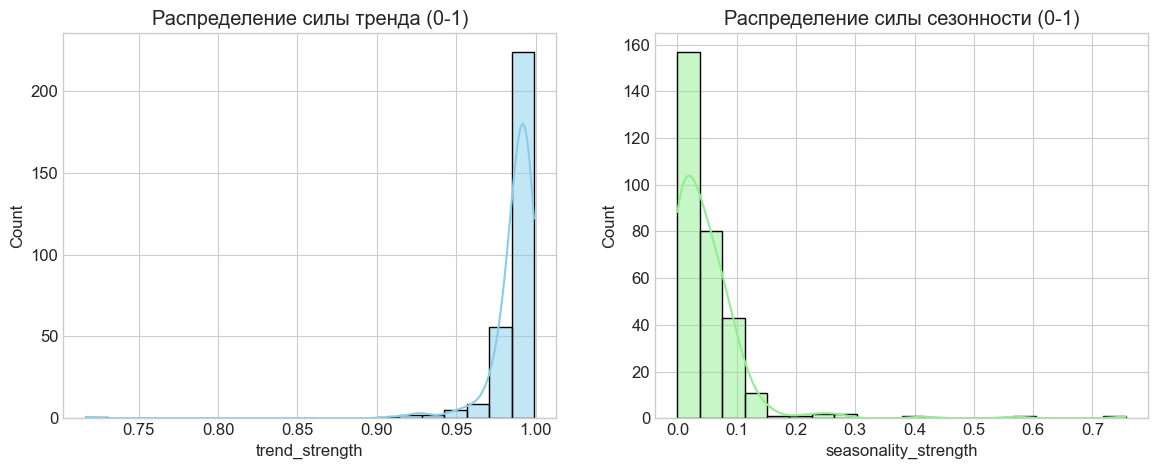

In [ ]:
eda_results = TimeSeriesEDA.analyze_dataset(series_dict, period=SEASONALITY)

adf_non_stat = (eda_results['adf_stationary'] == False).mean() * 100
kpss_non_stat = (eda_results['kpss_stationary'] == False).mean() * 100
print(f"Доля нестационарных рядов по ADF: {adf_non_stat:.2f}%")
print(f"Доля нестационарных рядов по KPSS: {kpss_non_stat:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_results['trend_strength'], bins=20, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Распределение силы тренда (0-1)')

sns.histplot(eda_results['seasonality_strength'], bins=20, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Распределение силы сезонности (0-1)')
plt.show()

Translation:

Share of non-stationary series by ADF: 95.67%       
Share of non-stationary series by KPSS: 96.33%         

**Conclusions on statistical tests (ADF/KPSS) and component strength:**

* About 96% of series reject the stationarity hypothesis.

* The `trend_strength` histogram shows that for the vast majority of series, trend strength tends toward 1.

* The `seasonality_strength` indicator for period 7 is close to zero for most series. Due to the specific nature of M4 data, calendar lags may not be entirely accurate, as financial indicators respond to news rather than calendar periods.

Therefore, diff transformation may be most appropriate for these series, as it will eliminate stationarity and allow only trend patterns to be assessed.

## 2. Optimizing the Number of Clusters
We use `tsfeatures` to divide the rows into homogeneous groups.
We determine the optimal number of clusters using the silhouette coefficient.

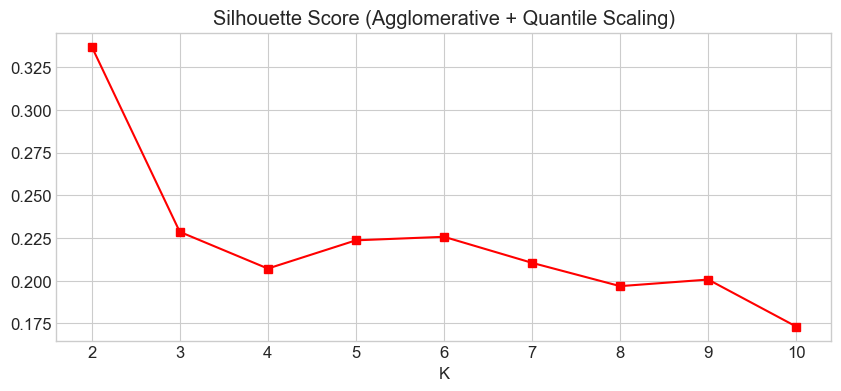

Распределение:
cluster
0    125
1     40
2     35
Name: count, dtype: int64


In [ ]:
features_df, scaled_features = TimeSeriesClustering.extract_features(series_dict, freq=7)

k_values, silhouette_scores = TimeSeriesClustering.calculate_cluster_metrics(scaled_features)

plt.figure(figsize=(10, 4))
plt.plot(k_values, silhouette_scores, marker='s', color='red')
plt.title("Silhouette Score (Agglomerative)")
plt.xlabel("K")
plt.grid(True)
plt.show()

cluster_dict, result_df = TimeSeriesClustering.assign_clusters(features_df, scaled_features, n_clusters=3)
print("Распределение:")
print(result_df['cluster'].value_counts())

In [ ]:
core_features = [c for c in result_df.columns if any(f in c for f in TimeSeriesClustering.M4_CORE_FEATURES)]

cluster_profiles = result_df.groupby('cluster')[core_features].mean()

print("Характеристики кластеров:")
display(cluster_profiles.T.style.background_gradient(cmap='RdYlGn', axis=1))

Характеристики кластеров:


cluster,0,1,2
hurst,0.986299,0.819824,1.028830
stability,0.989329,0.960137,0.999793
trend,0.995276,0.982922,0.998392
nonlinearity,0.037041,0.182361,0.035518
lumpiness,0.002818,0.083173,0.000045
entropy,0.276056,0.394236,0.210504


Translation:

Cluster characteristics

Although the best silhouette is achieved with two clusters, three clusters were chosen for the experiment, as each is a refinement of the other and will provide alternative insights into the application of a particular transformation.

* **Cluster 2: Simple Series**
- Maximum predictability. Perfectly smooth and stable trends (`Trend`: 0.998, `Stability`: 0.999), strong persistence (`Hurst` > 1).
- Minimal noise and virtually zero discontinuity in variance (`Lumpiness` approx. 0).
- Likely to be easily predicted by classical statistical models.

* **Cluster 0: Stable Series**
- Clear trends (`Trend`: 0.995), but with noticeable local noise (`Entropy`: 0.276).
- Extremely low nonlinearity. The series are easy to read but contain local fluctuations. 
- Similar to the second cluster, but noisier – CatBoost will likely be better at selecting patterns for it.

* **Cluster 1: Complex (chaotic) series**
- The most difficult series to forecast with a high degree of uncertainty.
- Leading in nonlinearity (0.182) and heteroscedasticity. Variance fluctuates over time (Lumpiness: 0.083). The trend is noticeably weaker (Hurst: 0.819).
- Classic models may not be able to handle these series without significant transformation.

## 3. Comparison of CatBoost and baseline metrics
Model quality was assessed using Walk-Forward cross-validation on an expanding window.

transform             boxcox                  diff               log1p  \
                        MASE     RMSE  sMAPE  MASE    RMSE sMAPE  MASE   
cluster model                                                            
0       AutoARIMA       2.65   415.49   6.94  0.95  181.83  2.33  0.96   
        AutoETS         2.65   415.57   6.94  0.96  183.27  2.37  0.97   
        AutoTheta       2.65   416.71   6.98  1.10  210.09  2.68  0.97   
        CatBoost_MIMO   4.40   736.62  10.66  0.96  183.40  2.32  1.27   
        Naive           2.65   416.87   6.94  2.61  520.63  6.23  0.97   
        SeasonalNaive   2.85   452.50   7.44  1.38  256.61  3.35  1.19   
1       AutoARIMA       6.11   886.57  22.59  1.05  214.35  2.86  1.01   
        AutoETS         6.10   883.67  22.56  1.04  210.24  2.88  0.99   
        AutoTheta       6.11   885.46  22.63  1.10  217.43  3.58  0.97   
        CatBoost_MIMO   9.18  1525.39  31.69  0.92  185.94  2.67  2.23   
        Naive           6.10   882.67  22.54  2.89  498.54  8.45  0.92   
        SeasonalNaive   6.35   924.15  23.12  1.31  247.72  4.01  1.26   
2       AutoARIMA       5.76  1069.43  14.54  1.11  219.06  2.35  1.12   
        AutoETS         5.65  1059.80  14.40  1.11  217.89  2.39  1.10   
        AutoTheta       5.77  1072.02  14.60  1.23  244.46  2.65  1.11   
        CatBoost_MIMO   6.73  1178.48  16.25  1.11  214.44  2.34  1.39   
        Naive           5.65  1059.09  14.40  2.64  480.43  5.35  1.10   
        SeasonalNaive   5.86  1104.09  14.92  1.55  321.07  3.32  1.33   

transform                            none                
                         RMSE sMAPE  MASE    RMSE sMAPE  
cluster model                                            
0       AutoARIMA      183.91  2.35  0.95  181.76  2.33  
        AutoETS        183.76  2.34  0.97  184.75  2.35  
        AutoTheta      184.32  2.36  0.96  183.63  2.37  
        CatBoost_MIMO  242.32  2.94  1.35  236.49  3.22  
        Naive          185.20  2.35  0.97  185.20  2.35  
        SeasonalNaive  227.36  2.88  1.19  227.36  2.88  
1       AutoARIMA      205.19  2.87  1.05  216.96  2.90  
        AutoETS        200.80  2.77  0.93  190.69  2.69  
        AutoTheta      193.15  2.80  0.93  189.37  2.72  
        CatBoost_MIMO  431.75  5.74  1.92  350.74  5.63  
        Naive          187.60  2.68  0.92  187.60  2.68  
        SeasonalNaive  248.56  3.43  1.26  248.56  3.43  
2       AutoARIMA      222.71  2.37  1.11  218.65  2.36  
        AutoETS        217.32  2.33  1.10  216.75  2.34  
        AutoTheta      219.54  2.38  1.11  219.94  2.42  
        CatBoost_MIMO  253.88  2.95  1.43  243.98  3.13  
        Naive          215.42  2.33  1.10  215.42  2.33  
        SeasonalNaive  266.13  2.89  1.33  266.13  2.89


AutoARIMA


transform,boxcox,diff,log1p,none
auto_params,,,,
"ARIMA(0, 0, 0, 0, 1, 0, 0)",0.0,251.0,0.0,0.0
"ARIMA(0, 0, 0, 0, 1, 1, 0)",239.0,0.0,242.0,270.0
"ARIMA(0, 1, 0, 0, 1, 0, 0)",0.0,52.0,0.0,0.0
"ARIMA(0, 1, 0, 0, 1, 1, 0)",70.0,0.0,62.0,55.0
"ARIMA(1, 1, 0, 0, 1, 1, 0)",40.0,0.0,43.0,31.0
"ARIMA(2, 2, 0, 0, 1, 0, 0)",0.0,43.0,0.0,0.0



AutoETS


transform,boxcox,diff,log1p,none
auto_params,,,,
"ETS(A,A,N)",26.0,0.0,0.0,0.0
"ETS(A,Ad,N)",29.0,12.0,39.0,0.0
"ETS(A,N,A)",0.0,25.0,0.0,0.0
"ETS(A,N,N)",527.0,559.0,379.0,257.0
"ETS(M,A,N)",0.0,0.0,0.0,66.0
"ETS(M,N,N)",0.0,0.0,133.0,206.0



AutoTheta


transform,boxcox,diff,log1p,none
auto_params,,,,
DOTM,107.0,108.0,82.0,86.0
OTM,299.0,387.0,146.0,214.0
STM,193.0,105.0,336.0,285.0


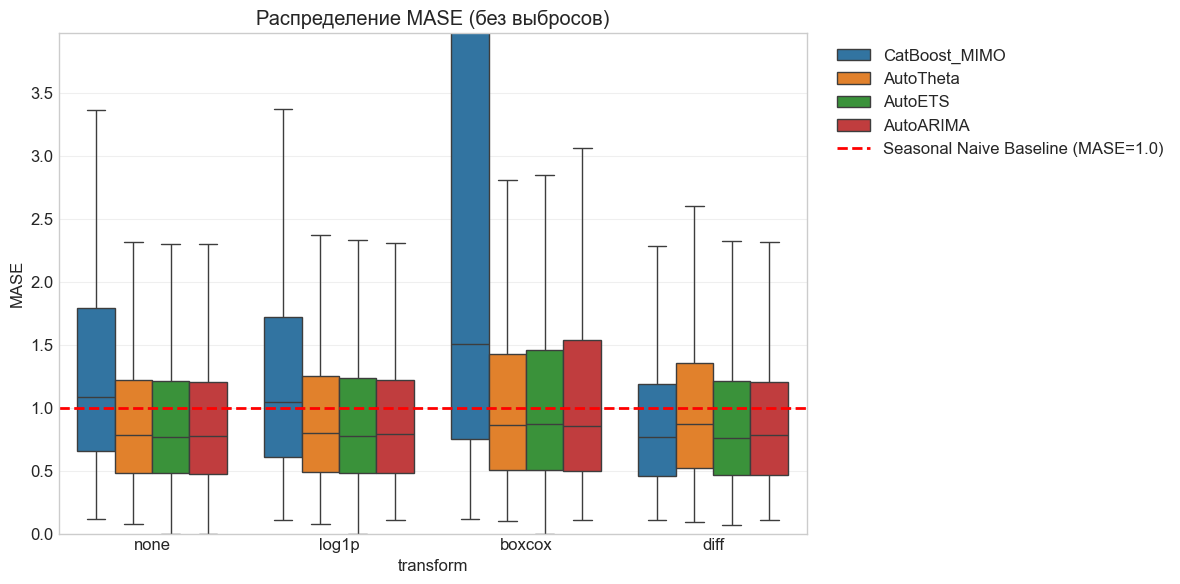

In [ ]:
metrics_file = os.path.join(RESULTS_DIR, 'metrics.csv')
df = pd.read_csv(metrics_file)

agg_df = df.groupby(['cluster', 'model', 'transform'])[['sMAPE', 'MASE', 'RMSE']].mean().reset_index()

pivot_all = agg_df.pivot_table(
    index=['cluster', 'model'], 
    columns='transform', 
    values=['sMAPE', 'MASE', 'RMSE']
)

pivot_clean = pivot_all.swaplevel(axis=1).sort_index(axis=1)

display(pivot_clean.round(2))

stat_models = ['AutoARIMA', 'AutoETS', 'AutoTheta']

for model_name in stat_models:
    model_df = df[df['model'] == model_name]
    if model_df.empty: continue
        
    print(f"\n{model_name}")
    params_count = model_df.groupby(['transform', 'auto_params']).size().reset_index(name='count')
    top_params = params_count.sort_values(['transform', 'count'], ascending=[True, False]).groupby('transform').head(3)
    
    top_pivot = top_params.pivot_table(index='auto_params', columns='transform', values='count', fill_value=0)
    display(top_pivot)

plot_df = df[~df['model'].isin(['Naive', 'SeasonalNaive'])]

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='transform', y='MASE', hue='model', showfliers=False)

plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Seasonal Naive Baseline (MASE=1.0)')
plt.title('Распределение MASE (без выбросов)')
max_y = plot_df['MASE'].quantile(0.95)
plt.ylim(0, max_y if pd.notna(max_y) else 2) 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusions on Metric Results

**1. The triumph of the global model on a complex cluster**

On chaotic time series with variable variance (Cluster 1), local statistical models perform the worst. However, the global CatBoostMIMO combined with differentiation (`diff`) demonstrated the absolute best result (MASE=0.92). Boosting successfully learned common nonlinear patterns across the entire cluster.

**2. Boosting's vulnerability to trends**

Without differentiation (`none`, `log1p`), CatBoost completely failed. It's likely that trees are unable to extrapolate values ​​beyond the historical window. Switching to incremental prediction (`diff`) is necessary.

**3. Classic approach for stable trends**

On smooth and predictable time series (Cluster 2), boosting is ineffective. AutoARIMA and AutoETS perform well on the original scale (none) or with logarithmization (log1p).

**4. Physical meaning of transformations confirmed**

Analysis of AutoETS parameters showed that on the original data, the algorithm often struggled with heteroscedasticity by choosing a multiplicative error (M). After log1p and diff, the series stabilized, and the algorithm largely switched to additive ETS(A,N,N) models.

**5. Box-Cox failure**

The power transformation (boxcox) showed disastrous results on all clusters. On noisy high-frequency data (Daily), inversion (exponentiation) greatly inflates even the smallest forecast errors. The method is unstable for this dataset.